#  Objectif global

Mettre en place un **Proof of Concept (POC)** visant à appliquer l’algorithme **LIME** sur un **modèle CNN** similaire à celui utilisé dans **RICA**.  

L’objectif final est de **mieux comprendre les décisions prises par le modèle**, en identifiant **quelles zones de l’image influencent ses prédictions**.


## Création d’un modèle de classification inspiré de YOLO (simplifié)

Objectif : construire un modèle de **classification par CNN** inspiré de YOLO, mais **plus simple** et **sans la partie régression** (localisation des objets).

### Architecture proposée
- **3 couches convolutionnelles (Conv)**  
  → Extraire progressivement les caractéristiques de l’image.
- **1 couche de pooling**  
  → Compresser les caractéristiques extraites et réduire la dimension spatiale.
- **Couches linéaires (Fully Connected)**  
  → Combiner les informations extraites et **prendre la décision de classification**.


In [21]:
import sys, os

from model.simple_cnn import SimpleCNN

model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


# Import des données MNIST

### sans rotations

In [10]:
import sys
import os

from data.import_data import ImportData

ImportData = ImportData()
trainloader, test_loader = ImportData.load_data_mnist(batch_size=32)
#trainloader, test_loader = ImportData.load_data(batch_size=32)
#test_loader = ImportData.load_data_rica(batch_size=3)
#trainloader, test_loader = ImportData.load_data_mnist_rota(batch_size=32)

print(len(test_loader.dataset))

Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data
MNIST — Nombre d'images train : 60000, test : 10000
10000


### avec rotations

Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].


MNIST — Nombre d'images train : 60000, test : 10000


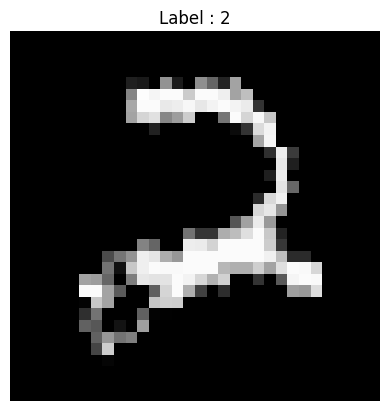

In [22]:
import sys
import os
import matplotlib.pyplot as plt

from data.import_data import ImportData

ImportData = ImportData()
#trainloader, test_loader = ImportData.load_data_mnist(batch_size=32)
#trainloader, test_loader = ImportData.load_data(batch_size=32)
#test_loader = ImportData.load_data_rica(batch_size=3)
trainloader, test_loader = ImportData.load_data_mnist_rota(batch_size=32)

# Récupérer un batch
images, labels = next(iter(trainloader))

# Sélectionner la première image du batch
img = images[0].numpy().transpose(1, 2, 0)  # (C,H,W) -> (H,W,C)

# Afficher
plt.figure()
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.title(f"Label : {labels[0].item()}")
plt.show()


# Check des résultats du model dans les deux cas 

### Param d'entrainement : 
- epochs = 5
- batch_size = 32
- lr = 1e-3

In [24]:
ckpt_path="/home/jmerhrioui/soprasteria/poc/train/cnn_mnist_ckpt.pth"
ckpt_path_rota="/home/jmerhrioui/soprasteria/poc/train/cnn_mnist__rota_ckpt.pth"
ckpt = [ckpt_path ,  ckpt_path_rota ]

In [25]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os, sys

from model.simple_cnn import SimpleCNN
from data.import_data import ImportData
from train.train_cnn import CNN  # classe qui contient train() et evaluate()
from data.import_data import ImportData

ImportData = ImportData()

for e in ckpt : 
    print ("path testé ", e )

    if e == ckpt_path : 
        trainloader, test_loader = ImportData.load_data_mnist(batch_size=32)
    else :
        trainloader, test_loader = ImportData.load_data_mnist_rota(batch_size=32)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Charger saved model 
    model = SimpleCNN().to(device)
    model.load_state_dict(torch.load(e, map_location=device))
    model.eval()
    
    test_loss, test_acc = CNN.evaluate(model, test_loader, device)
    print(f"Test Loss : {test_loss:.4f}")
    print(f"Test Accuracy : {test_acc:.2f}")


path testé  /home/jmerhrioui/soprasteria/poc/train/cnn_mnist_ckpt.pth
Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data
MNIST — Nombre d'images train : 60000, test : 10000

=== Résultats par classe ===
Chiffre 0 : 977/980 corrects (99.7%)
Chiffre 1 : 1134/1135 corrects (99.9%)
Chiffre 2 : 1029/1032 corrects (99.7%)
Chiffre 3 : 1008/1010 corrects (99.8%)
Chiffre 4 : 978/982 corrects (99.6%)
Chiffre 5 : 884/892 corrects (99.1%)
Chiffre 6 : 947/958 corrects (98.9%)
Chiffre 7 : 1016/1028 corrects (98.8%)
Chiffre 8 : 967/974 corrects (99.3%)
Chiffre 9 : 994/1009 corrects (98.5%)

=== Confusions les plus fréquentes ===
0 → 6 : 1 fois
0 → 7 : 1 fois
0 → 8 : 1 fois
1 → 2 : 1 fois
2 → 0 : 1 fois
2 → 7 : 2 fois
3 → 2 : 1 fois
3 → 5 : 1 fois
4 → 2 : 1 fois
4 → 9 : 3 fois
5 → 0 : 1 fois
5 → 3 : 5 fois
5 → 6 : 1 fois
5 → 9 : 1 fois
6 → 0 : 1 fois
6 → 1 : 3 fois
6 → 4 : 1 fois
6 → 5 : 4 fois
6 → 8 : 2 fois
7 → 1 : 3 fois
7 → 2 : 6 fois
7 → 8 : 1 fois
7 → 9 : 2

# On utilise SLIC pour diviser en superpixel notre image 

- **Principe :**
  1. Initialiser des centres régulièrement espacés sur l’image.
  2. Associer chaque pixel au centre le plus proche dans un voisinage local,
     en utilisant une **distance combinée couleur + position**.
  3. Mettre à jour la position de chaque centre comme la moyenne de ses pixels associés.
  4. Répéter les étapes 2–3 jusqu’à convergence.

- **Avantages :**
  - Superpixels compacts et réguliers
  - Calcul rapide et simple ( **slic(
                img,
                n_segments=self.n_segments,
                compactness=self.compactness,
                sigma=0,
                start_label=0
            )**)



Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data
MNIST — Nombre d'images train : 60000, test : 10000
Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data
MNIST — Nombre d'images train : 60000, test : 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1329083..1.1996739].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1464155..1.1925564].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1936538..1.2893103].


Superpixels sauvegardés dans /home/jmerhrioui/soprasteria/poc/test/test_img/superpixels.png


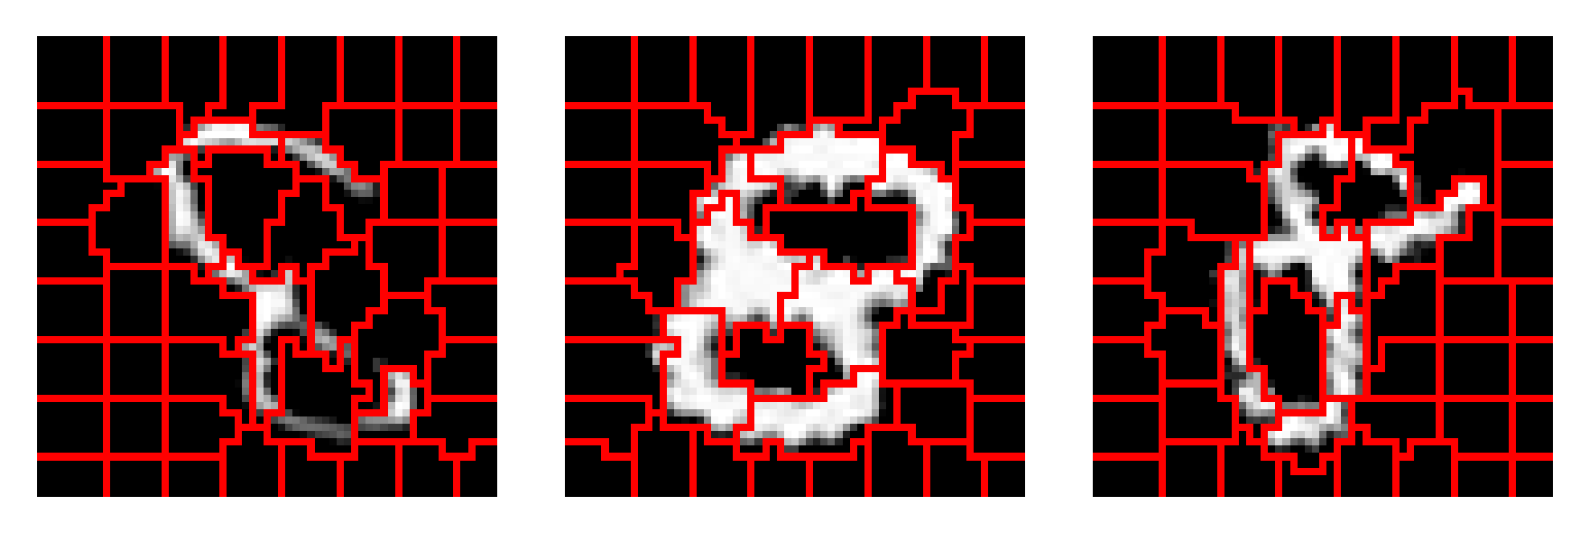

In [26]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import os
import sys
import matplotlib.pyplot as plt
from skimage.io import imread

from lime.super_pixels import superpixels
from data.import_data import ImportData


sp = superpixels(batch_size=3, n_segments=60, compactness=10, target_class=8, type_data = "mnist_rota") # type : mnist_rota, mnist, rica
# batch_size est ici le nombre d'images à récupérer dans une categorie
visus, segs , vis  = sp.superpixels()

# Afficher et sauvegarder les superpixels
sp.save_superpixels()

# Charger l'image
image = imread("/home/jmerhrioui/soprasteria/poc/test/test_img/superpixels.png")

plt.figure(figsize=(16, 6))        
plt.imshow(image)
plt.axis('off')                     
plt.tight_layout()                 
plt.show()

# Bruitage

### Méthode

- On récupère les superpixels
- On défini le nombre de perturbations ( images bruitées )
- On remplace aléatoirement un ou plusieurs superpixels par un fond noir
- On obtient une liste d'images plus ou moins bruitées

Téléchargement/chargement MNIST depuis : /home/jmerhrioui/soprasteria/poc/data/mnist_data
MNIST — Nombre d'images train : 60000, test : 10000


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15660214..1.1342388].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18394206..1.1341856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18565147..1.1256226].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15660262..1.1342989].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11903511..1.1342051].


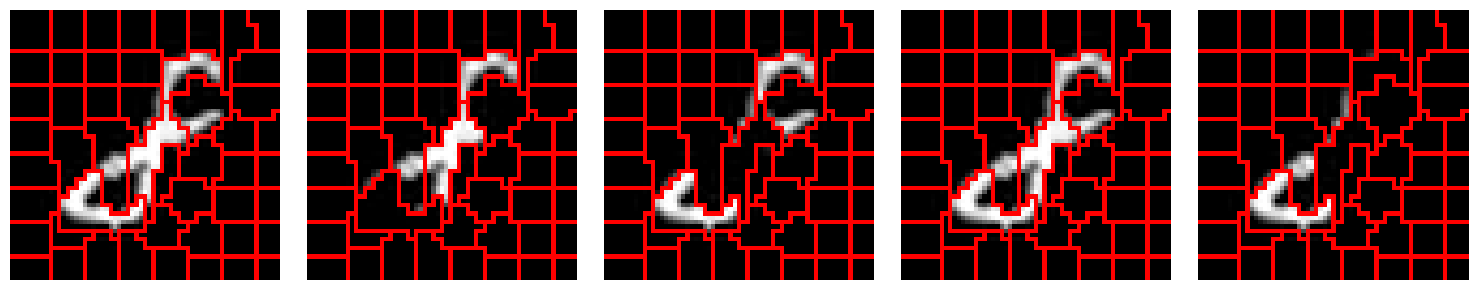

In [15]:
import numpy as np
import torch
from skimage.segmentation import slic
from skimage.util import img_as_float
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries


from lime.regression import regression
from data.import_data import ImportData

data = ImportData()

data_t = "mnist_rota"

if data_t == "mnist" : 
    _ , testloader = data.load_data_mnist(batch_size = 32)
if data_t == "mnist_rota" : 
    #_ , testloader = data.load_data_mnist_rota(batch_size = 32)  # si testloader alors shuffle = False 
    testloader , _ = data.load_data_mnist_rota(batch_size = 32)  # si trainloader alors shuffle = True 
if data_t == "cifar" : 
    _ , testloader = data.load_data(batch_size = 32)
if data_t == "rica" : 
    testloader = data.load_data_rica(batch_size = 32) # si testloader alors shuffle = False 

n_segments = 60
compactness = 10

# Récupérer une image du loader
x, y = next(iter(testloader))
img = x[0].numpy().transpose(1, 2, 0)  # (H,W,3)
img = img_as_float(img)

# Segmentation SLIC
seg = slic(img, n_segments=n_segments, compactness=compactness, sigma=0, start_label=0)
K = int(seg.max() + 1)

# Créer l'objet LIME
reg = regression(
    batch_size=5,
    n_segments=n_segments, 
    compactness=compactness,
    target_class=8,
    alpha=0.001
)

# Générer des images bruitées
images_bruitees, Z = reg.bruit(img, seg, K, n_perturb=1000)
#print(len(images_bruitees))

n = 5

fig , axes = plt.subplots ( 1, n , figsize=(15,3))
for i in range (n):
    img_with_contours = mark_boundaries(images_bruitees[i], seg, color=(1, 0, 0), mode='subpixel')
    axes[i].imshow(img_with_contours)
    axes[i].axis("off")

plt.tight_layout()
plt.show()


# Regression


### On transforme nos listes d'images bruitées en matrices binaires ( Z[i])

### On évalue chaque image bruité qui correspond à un (Z[i]) pour trouver la proba associée à une classe (y[i])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13501173..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12694646..1.0].


Z[0] = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
Z[1] = [0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.]


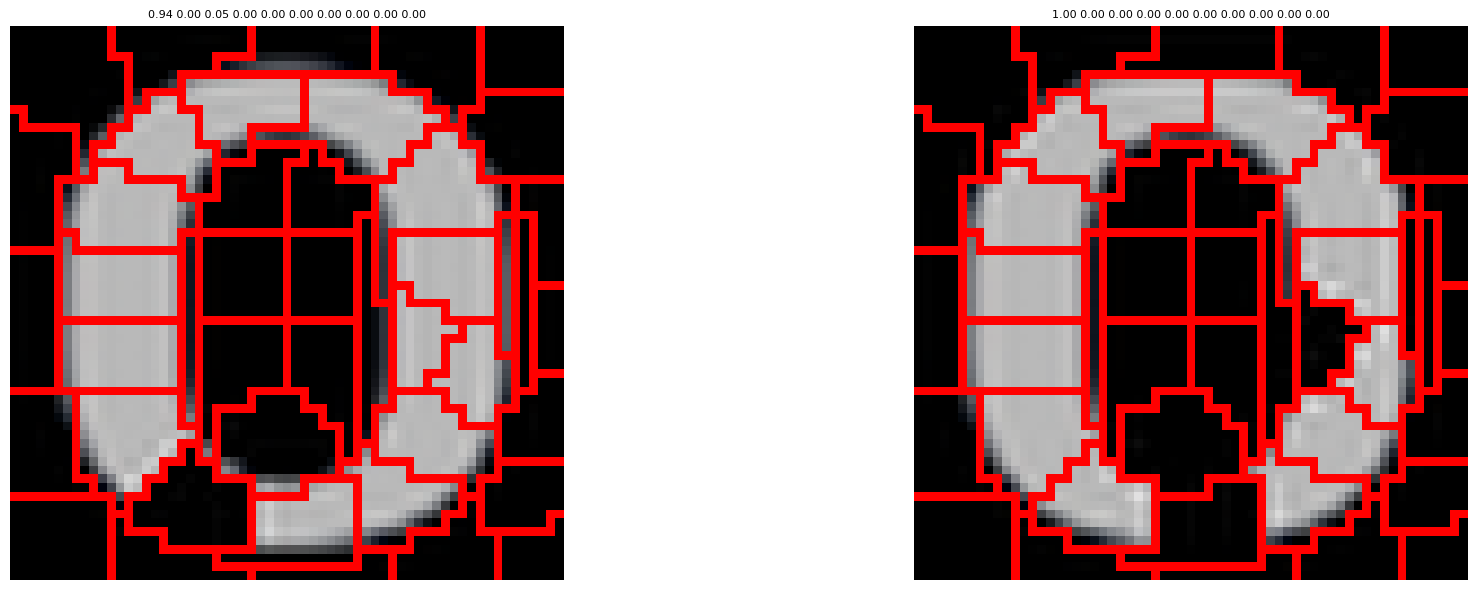

In [16]:
import numpy as np
import torch
import torch.nn.functional as F
from skimage.segmentation import slic
from skimage.util import img_as_float
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

from lime.regression import regression
from data.import_data import ImportData
from model.simple_cnn import SimpleCNN

data = ImportData()

data_t = "rica"

if data_t == "mnist" : 
    _ , testloader = data.load_data_mnist(batch_size = 32)
if data_t == "mnist_rota" : 
    #_ , testloader = data.load_data_mnist_rota(batch_size = 32)  # si testloader alors shuffle = False 
    testloader , _ = data.load_data_mnist_rota(batch_size = 32)  # si trainloader alors shuffle = True 
if data_t == "cifar" : 
    _ , testloader = data.load_data(batch_size = 32)
if data_t == "rica" : 
    testloader = data.load_data_rica(batch_size = 32) # si testloader alors shuffle = False 

n_segments = 60
compactness = 10

# Récupérer une image du loader
x, y = next(iter(testloader))
img = x[0].numpy().transpose(1, 2, 0)  # (H,W,3)
img = img_as_float(img)

# Segmentation SLIC
seg = slic(img, n_segments=n_segments, compactness=compactness, sigma=0, start_label=0)
K = int(seg.max() + 1)

# Créer l'objet LIME
reg = regression(
    batch_size=5,
    n_segments=n_segments, 
    compactness=compactness,
    target_class=8,
    alpha=0.001
)


images_bruitees, Z = reg.bruit(img, seg, K, n_perturb=1000)

#modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
model.load_state_dict(torch.load(
    "/home/jmerhrioui/soprasteria/poc/train/cnn_mnist_ckpt.pth",
    map_location=device))
model.eval()

# 10 probabilités complètes pour chaque image bruitée
probas_all = []
for img_b in images_bruitees:
    x_t = reg._to_model_tensor(img_b).to(device)
    with torch.no_grad():
        logits = model(x_t)
        probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    probas_all.append(probs)

probas_all = np.array(probas_all)  #  (n_perturb, 10)

#affichage
n = 2
fig , axes = plt.subplots ( 1, n , figsize=(21,6))
for i in range (n):
    img_with_contours = mark_boundaries(images_bruitees[i], seg, color=(1, 0, 0), mode='subpixel')
    axes[i].imshow(img_with_contours)
    axes[i].axis("off")

    # probas 
    probs_str = " ".join([f"{p:.2f}" for p in probas_all[i]])
    axes[i].set_title(probs_str, fontsize=8)

    print(f"Z[{i}] = {Z[i]}")
    #print(f"probas[{i}] = {np.round(probas_all[i],2)}")

plt.tight_layout()
plt.show()


### 4. Régression pondérée (Lasso)
- On ajuste un modèle `Lasso` (`sklearn.linear_model`) sur les données `(Z, y)` :

- lasso = Lasso(`alpha=0.0001`) ici lasso et le coeff de penalisation
- lasso.fit(Z, y, sample_weight=`weights`)
- w = lasso.coef_

#### weights = Poid gaussien : 

- Idée : si un superpixel seul fait varier le score il doit avoir plus d'importance qui si n pixels font le même changement

**Sortie :**
- `w` : vecteur `(K,)` contenant l’**importance normalisée de chaque superpixel** dans la décision du CNN



In [17]:
import torch 
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.linear_model import Lasso
from skimage.util import img_as_float
from skimage.segmentation import slic


from lime.regression import regression
from lime.regression import regression
from data.import_data import ImportData
from model.simple_cnn import SimpleCNN

data = ImportData()

data_t = "rica"

if data_t == "mnist" : 
    _ , testloader = data.load_data_mnist(batch_size = 32)
if data_t == "mnist_rota" : 
    #_ , testloader = data.load_data_mnist_rota(batch_size = 32)  # si testloader alors shuffle = False 
    testloader , _ = data.load_data_mnist_rota(batch_size = 32)  # si trainloader alors shuffle = True 
if data_t == "cifar" : 
    _ , testloader = data.load_data(batch_size = 32)
if data_t == "rica" : 
    testloader = data.load_data_rica(batch_size = 32) # si testloader alors shuffle = False 

n_segments = 60
compactness = 10

# Récupérer une image du loader
x, y = next(iter(testloader))
img = x[0].numpy().transpose(1, 2, 0)  # (H,W,3)
img = img_as_float(img)

# Segmentation SLIC
seg = slic(img, n_segments=n_segments, compactness=compactness, sigma=0, start_label=0)

batch_size=2
target_class = 8

reg = regression(
    batch_size=batch_size, # nombre d'images à afficher 
    n_segments=50,
    compactness= 10,
    target_class=target_class,
    alpha=0.0001
)

w = reg.regression(image = img , seg = seg)
print ("poids pour une image ", w)

[DEBUG] Image: (32, 32, 3), superpixels=44, classe=8
[RESULTATS] Poids superpixels normalisés : [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0. -1. -0. -0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0.  0.
  0.  0. -0. -0.  0.  0.  0.  0.]
poids pour une image  [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0. -1. -0. -0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0.  0.
  0.  0. -0. -0.  0.  0.  0.  0.]


[INFO] Trouvé 3 corrects et 0 erreurs pour la classe 7
[DEBUG] Image: (32, 32, 3), superpixels=26, classe=7


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024629187..1.0295902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.188657..1.2614144].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.050751667..1.0678248].


[RESULTATS] Poids superpixels normalisés : [-0.     0.    -0.    -0.     0.    -0.     0.     1.    -0.    -0.
  0.     0.    -0.    -0.     0.     0.     0.266  0.    -0.    -0.
 -0.    -0.    -0.    -0.    -0.     0.023]
[INFO] Image sauvegardée : /home/jmerhrioui/soprasteria/poc/test/top_results/lime_0_true7.png
[DEBUG] Image: (32, 32, 3), superpixels=30, classe=7


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.031360462..1.0584867].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19684333..1.3216364].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.081476904..1.0856069].


[RESULTATS] Poids superpixels normalisés : [ 0.    -0.    -0.    -0.     0.     0.     0.012 -0.     1.    -0.
  0.    -0.    -0.    -0.     0.085  0.     0.     0.011  0.    -0.
 -0.     0.    -0.005 -0.     0.     0.     0.     0.039 -0.    -0.   ]
[INFO] Image sauvegardée : /home/jmerhrioui/soprasteria/poc/test/top_results/lime_1_true7.png


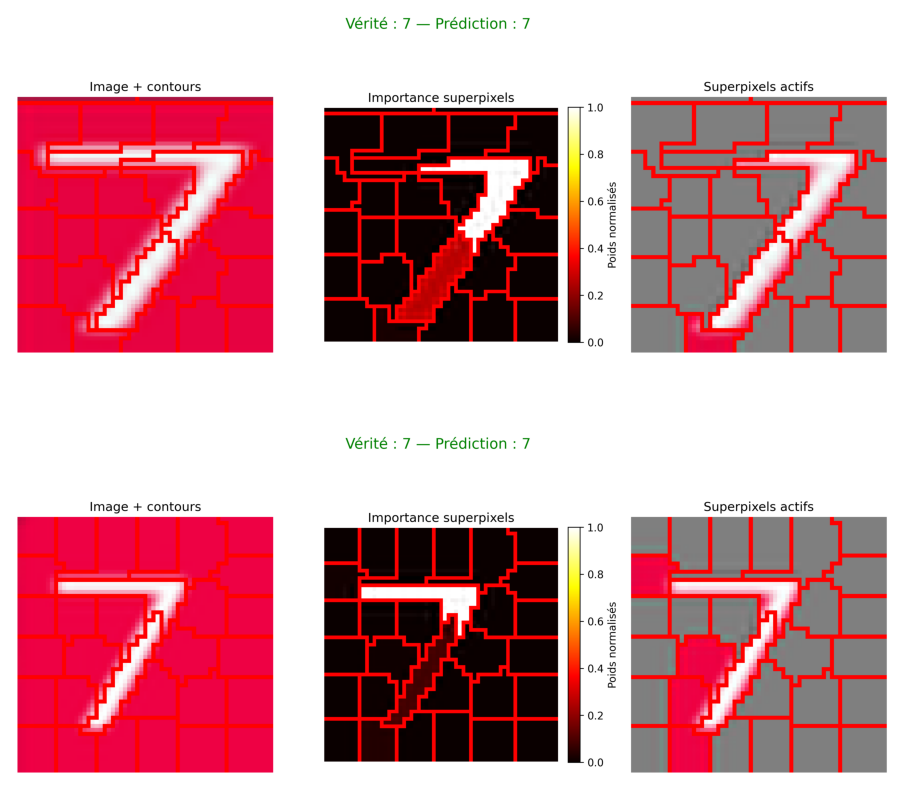

In [48]:
import os, sys
from skimage.io import imread
import matplotlib.pyplot as plt

from lime.regression import regression

batch_size= 2
target_class = 7

reg = regression(
    batch_size=batch_size, # nombre d'images à afficher 
    n_segments=50,
    compactness= 10,
    target_class=target_class,
    alpha=0.0005
)
reg.visualiser_top_superpixels(out_dir="/home/jmerhrioui/soprasteria/poc/test/top_results") # attentioon ckpt à changer dans fct + data load
# l.110 - 117
n= batch_size
path = "/home/jmerhrioui/soprasteria/poc/test/top_results"

fig , axes =  plt.subplots(n , 1, figsize =(40,10))
for i in range (n) :
    lien = os.path.join(path, f"lime_{i}_true{target_class}.png")
    image = imread(lien)
    axes[i].imshow(image)
    axes[i].axis("off")

plt.show()

# Mise en place d'un score d'explicabilité 

### Idée de base : Il faut que les N pixels les plus importants correspondent aux pixels présent sur le chiffre
- N va dépendre de la taille du nombre
- On pose N = nombre de superpixels différents du fond ( luminance  )
- On choisi alpha très faible pour que nbre de superpixels intéressant soit supérieur à N 

/tmp/ipykernel_2435/2686655117.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_in = torch.tensor(x[image_idx].unsqueeze(0)).to(device)


[DEBUG] Image: (32, 32, 3), superpixels=46, classe=3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77254903..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7916831..1.0154403].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.068721].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23237756..1.0995904].


[RESULTATS] Poids superpixels normalisés : [ 0.01  -0.056 -0.338 -0.089 -0.227 -0.033 -0.035  0.023 -0.065  0.004
  0.021 -0.06  -0.028 -0.011 -0.883 -0.022  0.045  0.346 -0.059 -1.
  0.105 -0.131 -0.098  0.031 -0.122 -0.055  0.17   0.007 -0.026 -0.075
 -0.02   0.025 -0.035 -0.068 -0.06  -0.1    0.139  0.075 -0.06   0.072
 -0.066 -0.004 -0.055 -0.062 -0.027 -0.036]
[SCORE] Digit=22, Top=22, Corrects=9, Score=0.41
Score de recouvrement : 0.41


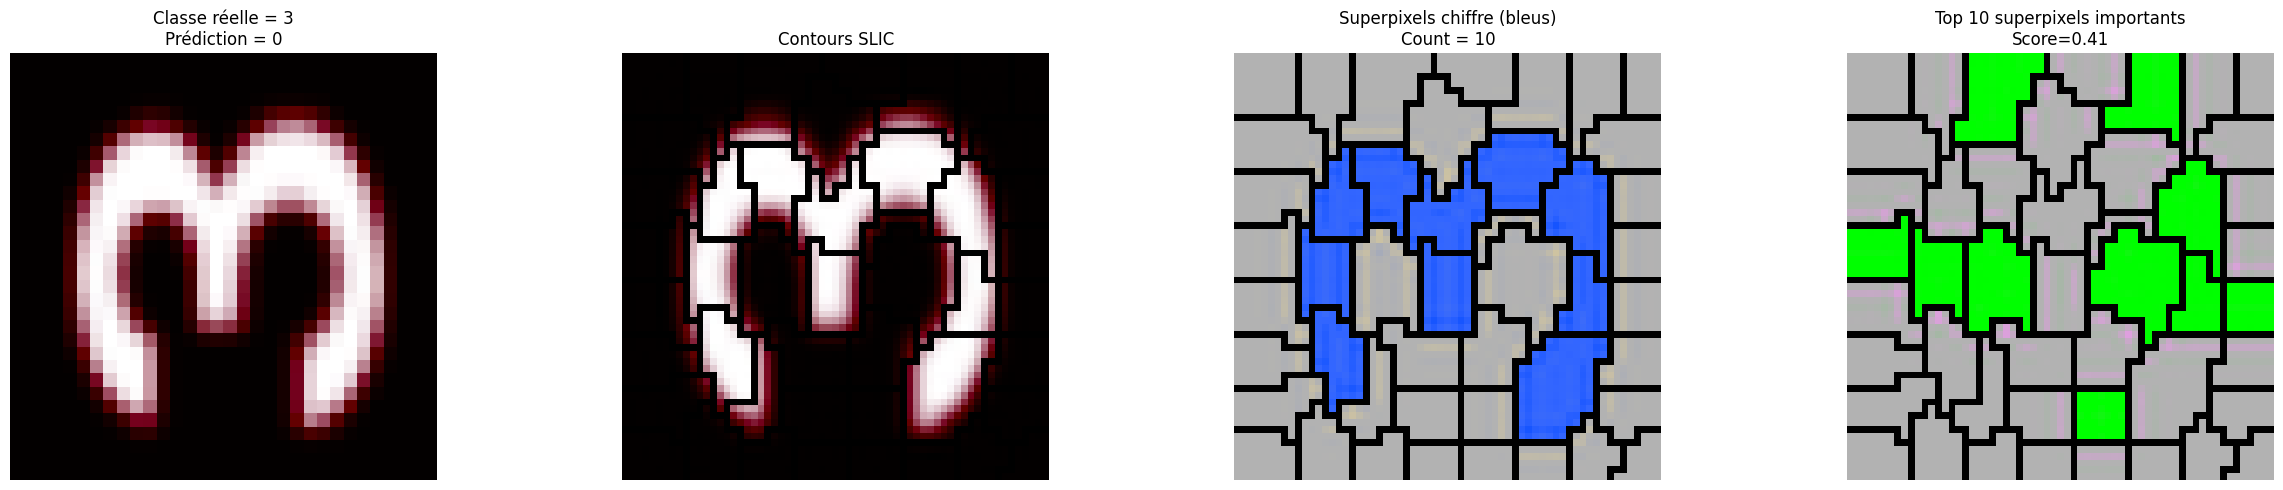

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.util import img_as_float
from skimage.segmentation import slic, mark_boundaries
import torch
import torch.nn.functional as F
from skimage.filters import threshold_otsu

from lime.regression import regression
from data.import_data import ImportData
from model.simple_cnn import SimpleCNN

# Charger les données
data = ImportData()
testloader = data.load_data_rica(batch_size=32)

# Récupérer une image
x, y = next(iter(testloader))
image_idx = 11
img = x[image_idx].numpy().transpose(1, 2, 0)
img = img_as_float(img)
true_class = int(y[image_idx].item())

# Segmentation SLIC
n_segments = 60
compactness = 14
seg = slic(img, n_segments=n_segments, compactness=compactness, sigma=0, start_label=0)

# Charger le modèle et prédire
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
model.load_state_dict(torch.load(
    "/home/jmerhrioui/soprasteria/poc/train/cnn_mnist_ckpt.pth",
    map_location=device))
model.eval()

with torch.no_grad():
    x_in = torch.tensor(x[image_idx].unsqueeze(0)).to(device)
    logits = model(x_in)
    pred_class = torch.argmax(F.softmax(logits, dim=1), dim=1).item()

# Créer l'objet regression
reg = regression(
    batch_size=1,
    n_segments=n_segments,
    compactness=compactness,
    target_class=true_class,
    alpha=1e-8
)

# LIME
w = reg.regression(img, seg)
score = reg.score_recouvrement(img, seg, w)
print(f"Score de recouvrement : {score:.2f}")

# ----- Détection des superpixels blancs -----
gray = img.mean(axis=2)
th = threshold_otsu(gray)

digit_sp = []
for sp_id in range(int(seg.max() + 1)):
    sp_mask = (seg == sp_id)
    if (gray[sp_mask] > th).mean() > 0.5:
        digit_sp.append(sp_id)

mask_digit_sp = np.isin(seg, digit_sp)

# Top superpixels
top_sp = np.argsort(np.abs(w))[::-1][:len(digit_sp)]
mask_top = np.isin(seg, top_sp)

# ----- Création images colorées -----
img_gray = np.ones_like(img) * 0.7

# zone des superpixels blancs
zone_blanche = img_gray.copy()
zone_blanche[mask_digit_sp] = [0.2, 0.4, 1.0]
zone_blanche = mark_boundaries(zone_blanche, seg, color=(0,0,0), mode='subpixel')

# zone des top superpixels
zone_top = img_gray.copy()
zone_top[mask_top] = [0.0, 1.0, 0.0]
zone_top = mark_boundaries(zone_top, seg, color=(0,0,0), mode='subpixel')

# ----- Affichage -----
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

axes[0].imshow(img); axes[0].axis("off")
axes[0].set_title(f"Classe réelle = {true_class}\nPrédiction = {pred_class}")

axes[1].imshow(mark_boundaries(img, seg, color=(0,0,0), mode='subpixel'))
axes[1].axis("off")
axes[1].set_title("Contours SLIC")

axes[2].imshow(zone_blanche); axes[2].axis("off")
axes[2].set_title(f"Superpixels chiffre (bleus)\nCount = {len(digit_sp)}")

axes[3].imshow(zone_top); axes[3].axis("off")
axes[3].set_title(f"Top {len(digit_sp)} superpixels importants\nScore={score:.2f}")

plt.tight_layout()
plt.show()


# Evaluation de ma méthode 

### On fixe un score ( ex : 0.5 ) 

In [20]:
import torch
import torch.nn.functional as F
import numpy as np
from skimage.util import img_as_float
from skimage.segmentation import slic
from skimage.filters import threshold_otsu
from tqdm import tqdm

from data.import_data import ImportData
from model.simple_cnn import SimpleCNN
from lime.regression import regression

# --- Charger les données ---
data = ImportData()
testloader = data.load_data_rica(batch_size=32)

# --- Charger le modèle ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
model.load_state_dict(torch.load(
    "/home/jmerhrioui/soprasteria/poc/train/cnn_mnist__rota_ckpt.pth",
    map_location=device))
model.eval()

# --- Créer l'objet regression ---
reg = regression(
    batch_size=32,  # on fait toute les images d'un coup
    n_segments=60,
    compactness=10,
    target_class=None,
    alpha=1e-8
)

# --- Compteurs confusion ---
VP = FP = VN = FN = 0

# --- Parcourir toutes les images ---
with torch.no_grad():
    for x, y in tqdm(testloader, desc="Évaluation"):
        for i in range(len(x)):
            true_class = int(y[i].item())
            img = x[i].numpy().transpose(1, 2, 0)
            img = img_as_float(img)

            # Prédiction CNN
            logits = model(x[i].unsqueeze(0).to(device))
            pred_class = torch.argmax(F.softmax(logits, dim=1), dim=1).item()
            correct = (pred_class == true_class)

            # Segmentation
            seg = slic(img, n_segments=60, compactness=10, sigma=0, start_label=0)

            # Régression LIME
            reg.target_class = true_class
            w = reg.regression(img, seg)

            # --- Calcul du recouvrement (superpixels) ---
            gray = img.mean(axis=2)
            th = threshold_otsu(gray)

            digit_sp = []
            for sp_id in range(int(seg.max() + 1)):
                sp_mask = (seg == sp_id)
                if (gray[sp_mask] > th).mean() > 0.5:
                    digit_sp.append(sp_id)

            top_sp = np.argsort(np.abs(w))[::-1][:len(digit_sp)]
            top_set = set(top_sp)
            digit_set = set(digit_sp)

            inter = len(top_set & digit_set)
            score = inter / len(top_set) if len(top_set) > 0 else 0.0

            # --- Prédiction "recouvrement" ---
            pred_correct = (score >= 0.4)

            # --- Confusion ---
            if correct and pred_correct:
                VP += 1
            elif not correct and pred_correct:
                FP += 1
            elif not correct and not pred_correct:
                VN += 1
            elif correct and not pred_correct:
                FN += 1

# --- Résultat ---
print("\n=== MATRICE DE CONFUSION ===")
print(f"Vrai Positif  (VP): {VP}")
print(f"Faux Positif  (FP): {FP}") # ccn se trompe mais je lui fais confiance 
print(f"Vrai Négatif  (VN): {VN}")
print(f"Faux Négatif  (FN): {FN}")

accuracy = (VP + VN) / (VP + FP + VN + FN + 1e-8)
print(f"\nPrécision globale : {accuracy:.2f}")


Évaluation:   0%|                                                   | 0/1 [00:00<?, ?it/s]

[DEBUG] Image: (32, 32, 3), superpixels=44, classe=0


/home/jmerhrioui/soprasteria/poc/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.200e+00, tolerance: 1.242e-02
  model = cd_fast.enet_coordinate_descent(


[RESULTATS] Poids superpixels normalisés : [-0.014  0.073  0.025 -0.047 -0.003 -0.182 -0.11   0.017 -0.043 -0.026
  0.022 -0.02   0.007  0.48  -0.032 -0.062 -0.027  0.014  0.685 -0.037
  0.053  0.033  0.918  0.024 -0.038 -0.022  1.     0.005 -0.038  0.573
  0.02  -0.028  0.611 -0.015  0.616  0.06  -0.038 -0.012  0.01  -0.045
 -0.01  -0.026 -0.013  0.004]
[DEBUG] Image: (32, 32, 3), superpixels=37, classe=0
[RESULTATS] Poids superpixels normalisés : [-0.035 -0.034  0.002 -0.021 -0.046  0.03  -0.037  0.532 -0.01  -0.043
 -0.003 -0.013 -0.036  1.    -0.16  -0.031  0.48  -0.018  0.019 -0.041
 -0.02   0.773 -0.004 -0.036  0.533 -0.019  0.003  0.387 -0.003  0.633
 -0.025  0.133  0.066  0.003 -0.03  -0.016 -0.021]
[DEBUG] Image: (32, 32, 3), superpixels=45, classe=0
[RESULTATS] Poids superpixels normalisés : [-0.009 -0.031 -0.04   0.043  0.002  0.003 -0.013 -0.005  0.024  0.066
  0.041 -0.015 -0.023 -0.007  0.001  1.    -0.01   0.066  0.007  0.004
  0.009  0.015 -0.059  0.025  0.019  0.425  0

/home/jmerhrioui/soprasteria/poc/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.084e-02, tolerance: 4.792e-03
  model = cd_fast.enet_coordinate_descent(


...

[RESULTATS] Poids superpixels normalisés : [-0.027 -0.02  -0.019 -0.01   0.038 -0.024  0.08  -0.012 -0.005  0.991
 -0.027 -0.01  -0.006 -0.019 -0.017  1.    -0.02  -0.014 -0.018 -0.004
  0.617 -0.014 -0.014  0.008  0.955 -0.013  0.012 -0.022 -0.026 -0.014
 -0.01  -0.002]
[DEBUG] Image: (32, 32, 3), superpixels=38, classe=9
[RESULTATS] Poids superpixels normalisés : [-0.083 -0.06  -0.024 -0.011 -0.036  0.649  0.67  -0.074  0.979  0.475
 -0.053 -0.04   0.053  0.672 -0.014  0.488  1.    -0.029  0.922 -0.021
  0.279  0.768 -0.046 -0.012  0.48  -0.066 -0.05   0.019 -0.008  0.035
  0.096 -0.034 -0.059 -0.026 -0.038 -0.014 -0.077 -0.012]
[DEBUG] Image: (32, 32, 3), superpixels=36, classe=9


/home/jmerhrioui/soprasteria/poc/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.450e-01, tolerance: 1.264e-02
  model = cd_fast.enet_coordinate_descent(


[RESULTATS] Poids superpixels normalisés : [-0.056  0.029  0.026 -0.06  -0.033  0.694  0.632 -0.041 -0.017  1.
 -0.07   0.084 -0.05   0.901  0.869 -0.066  0.778 -0.066  0.464 -0.024
 -0.055  0.678 -0.087 -0.047 -0.042  0.225 -0.004  0.004 -0.083 -0.047
 -0.022 -0.016 -0.044 -0.034 -0.012 -0.014]
[DEBUG] Image: (32, 32, 3), superpixels=40, classe=9


/home/jmerhrioui/soprasteria/poc/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.203e-01, tolerance: 1.151e-02
  model = cd_fast.enet_coordinate_descent(
Évaluation: 100%|███████████████████████████████████████████| 1/1 [00:19<00:00, 19.45s/it]

[RESULTATS] Poids superpixels normalisés : [-0.038 -0.059  0.007  0.01  -0.028  0.709  0.196  0.088  0.017  1.
  0.018  0.011 -0.063 -0.002 -0.003  0.582 -0.045 -0.042  0.995  0.003
 -0.054  0.159 -0.002  0.7   -0.006 -0.06  -0.006 -0.031 -0.054 -0.044
 -0.035 -0.018 -0.023  0.542 -0.005 -0.043  0.005 -0.04  -0.027 -0.024]

=== MATRICE DE CONFUSION ===
Vrai Positif  (VP): 21
Faux Positif  (FP): 9
Vrai Négatif  (VN): 1
Faux Négatif  (FN): 1

Précision globale : 0.69
